<a href="https://colab.research.google.com/github/camis08/IA_UC4/blob/main/UC4_Aula6_Correlacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula – Correlação: Relação entre Variáveis e Descoberta de Padrões

## UC4 – Estatística aplicada à Inteligência Artificial

### Objetivos da aula
- Entender o que é correlação e por que ela é importante.
- Identificar relações positivas, negativas, fracas, fortes e inexistentes.
- Interpretar gráficos de dispersão.
- Calcular e interpretar o coeficiente de correlação de Pearson.
- Entender por que correlação não significa causalidade.
- Usar correlação para investigar padrões em dados.
- Aplicar correlação na preparação de dados para IA.
- Construir matriz de correlação e heatmap.
- Resolver exercícios conceituais, visuais e práticos em Python.

,## Roteiro da aula

1. Revisão: variável, média, desvio padrão e dispersão  
2. O que é correlação  
3. Relação entre duas variáveis  
4. Correlação positiva, negativa e inexistente  
5. Gráfico de dispersão  
6. Coeficiente de correlação de Pearson  
7. Interpretação de valores entre -1 e +1  
8. Correlação forte, moderada e fraca  
9. Correlação não é causalidade  
10. Correlação espúria  
11. Matriz de correlação  
12. Heatmap  
13. Aplicações em IA  
14. Ponte para regressão  
15. Exercícios progressivos  
16. Desafio final

## 1. Revisão rápida

Até aqui estudamos conceitos importantes:

- **média**: mostra o centro dos dados;
- **mediana**: mostra o valor central;
- **moda**: mostra o valor mais frequente;
- **quartis**: mostram como os dados se distribuem;
- **amplitude**: mostra a diferença entre o maior e o menor valor;
- **variância e desvio padrão**: mostram o quanto os dados se espalham;
- **z-score**: mostra quantos desvios padrão um valor está distante da média.

Agora vamos dar um passo importante:

> Em vez de analisar apenas uma variável, vamos analisar a relação entre duas variáveis.

## 2. Motivação

Imagine as perguntas:

- Quem estuda mais tira nota maior?
- Pessoas com mais experiência ganham salários maiores?
- Quanto mais publicidade uma empresa faz, mais ela vende?
- Quanto maior o tempo de entrega, menor a satisfação do cliente?
- Quanto mais tempo uma pessoa passa em um aplicativo, mais compras ela realiza?

Todas essas perguntas envolvem a relação entre duas variáveis.

Essa relação é estudada por meio da **correlação**.

## 3. O que é correlação?

Correlação é uma medida estatística que indica se duas variáveis estão relacionadas.

Ela tenta responder:

> Quando uma variável muda, a outra tende a mudar também?

Exemplo:

Se as horas de estudo aumentam e as notas também aumentam, dizemos que existe uma correlação positiva entre horas de estudo e nota.

Se o tempo de atraso aumenta e a satisfação diminui, dizemos que existe uma correlação negativa.

Se uma variável muda e a outra não apresenta padrão, dizemos que há pouca ou nenhuma correlação.

## 4. Importante: correlação analisa associação, não causa

Correlação mostra que duas variáveis se movem juntas de alguma forma.

Mas ela não prova que uma causa a outra.

Exemplo:

Em dias quentes:
- vendas de sorvete aumentam;
- casos de afogamento também aumentam.

Existe correlação positiva entre venda de sorvete e afogamentos.

Mas sorvete não causa afogamento.

A variável escondida é o calor.

Esse é um dos erros mais comuns em análise de dados.

## 5. Tipos de correlação

### Correlação positiva
Quando uma variável aumenta, a outra também tende a aumentar.

Exemplos:
- horas de estudo e nota;
- investimento em publicidade e vendas;
- experiência profissional e salário.

### Correlação negativa
Quando uma variável aumenta, a outra tende a diminuir.

Exemplos:
- tempo de atraso e satisfação;
- preço e quantidade demandada;
- tempo sem manutenção e desempenho de máquina.

### Correlação próxima de zero
Quando não existe um padrão claro entre as variáveis.

Exemplos:
- número do calçado e nota em estatística;
- cor favorita e salário;
- dia do aniversário e tempo de uso de um aplicativo.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuração simples para os gráficos
plt.rcParams["figure.figsize"] = (8, 5)

## 6. Visualizando correlação positiva

No exemplo abaixo, conforme `x` aumenta, `y` também aumenta.

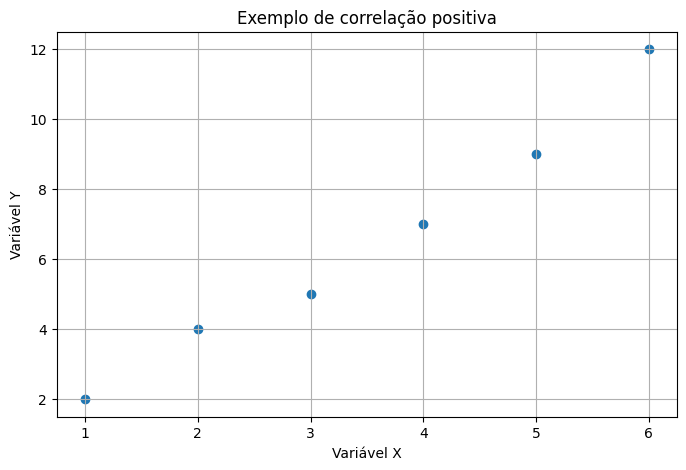

In [48]:
#Gráfico
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([2, 4, 5, 7, 9, 12])

plt.scatter(x, y)
plt.title("Exemplo de correlação positiva")
plt.xlabel("Variável X")
plt.ylabel("Variável Y")
plt.grid(True)
plt.show()

In [49]:
np.corrcoef(x, y)[0, 1]

np.float64(0.9894756991532591)

## 7. Visualizando correlação negativa

No exemplo abaixo, conforme `x` aumenta, `y` diminui.

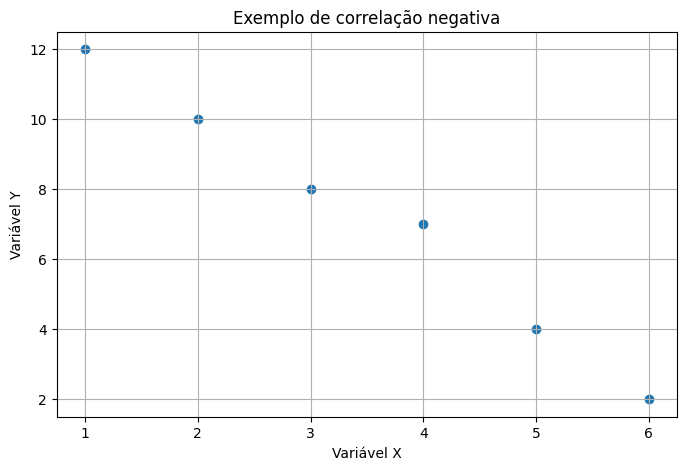

np.float64(-0.9940326972052328)

In [50]:
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([12, 10, 8, 7, 4, 2])

plt.scatter(x, y)
plt.title("Exemplo de correlação negativa")
plt.xlabel("Variável X")
plt.ylabel("Variável Y")
plt.grid(True)
plt.show()

np.corrcoef(x, y)[0, 1]

## 8. Visualizando ausência de correlação

No exemplo abaixo, não aparece um padrão claro entre as variáveis.

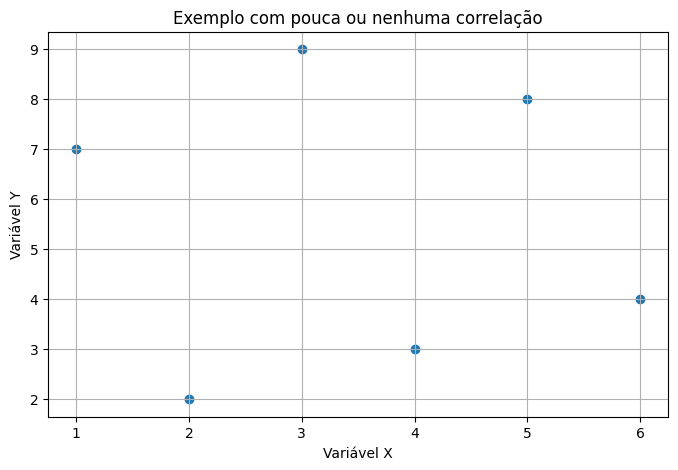

np.float64(-0.055660638808448334)

In [51]:
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([7, 2, 9, 3, 8, 4])

plt.scatter(x, y)
plt.title("Exemplo com pouca ou nenhuma correlação")
plt.xlabel("Variável X")
plt.ylabel("Variável Y")
plt.grid(True)
plt.show()

np.corrcoef(x, y)[0, 1]

## 9. Gráfico de dispersão

O gráfico mais importante para estudar correlação é o **gráfico de dispersão**, também chamado de **scatter plot**.

Cada ponto representa uma observação.

Exemplo:

| Horas de estudo | Nota |
|---|---|
| 1 | 3 |
| 2 | 4 |
| 3 | 6 |
| 4 | 7 |
| 5 | 8 |
| 6 | 9 |

Cada aluno vira um ponto no gráfico.

### O que observar no gráfico
- Os pontos sobem? Correlação positiva.
- Os pontos descem? Correlação negativa.
- Os pontos ficam espalhados sem padrão? Correlação fraca ou inexistente.
- Os pontos ficam muito próximos de uma linha? Correlação forte.
- Os pontos ficam muito espalhados? Correlação fraca.

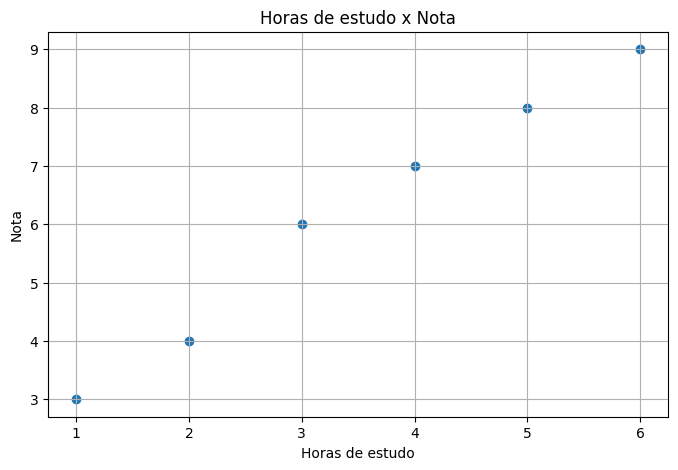

np.float64(0.9921609337929049)

In [52]:
horas_estudo = np.array([1, 2, 3, 4, 5, 6])
notas = np.array([3, 4, 6, 7, 8, 9])

plt.scatter(horas_estudo, notas)
plt.title("Horas de estudo x Nota")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota")
plt.grid(True)
plt.show()

np.corrcoef(horas_estudo, notas)[0, 1]

## 10. Coeficiente de correlação de Pearson

O coeficiente de correlação mais comum é o **coeficiente de Pearson**.

Ele mede a força e a direção da relação linear entre duas variáveis.

### Fórmula

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}
$$

Você não precisa decorar essa fórmula para usar no Python, mas precisa entender a ideia:

- se X e Y sobem juntos, a correlação tende a ser positiva;
- se X sobe e Y desce, a correlação tende a ser negativa;
- se não há padrão, a correlação fica próxima de zero.

## 11. Interpretação do coeficiente de correlação

O coeficiente de correlação varia entre -1 e +1.

| Valor de r | Interpretação |
|---|---|
| r = +1 | Correlação positiva perfeita |
| r próximo de +1 | Correlação positiva forte |
| r próximo de 0 | Correlação fraca ou inexistente |
| r próximo de -1 | Correlação negativa forte |
| r = -1 | Correlação negativa perfeita |

### Regra prática

| Intervalo aproximado | Força da correlação |
|---|---|
| 0,00 a 0,19 | Muito fraca |
| 0,20 a 0,39 | Fraca |
| 0,40 a 0,59 | Moderada |
| 0,60 a 0,79 | Forte |
| 0,80 a 1,00 | Muito forte |

Atenção: essa classificação é apenas uma referência. Em dados reais, o contexto importa muito.

## 12. Exemplo: horas de estudo e nota

Vamos criar uma pequena base de alunos.

In [53]:
df_alunos = pd.DataFrame({
    "aluno": ["Ana", "Bruno", "Carlos", "Diana", "Eduardo", "Fernanda", "Gabriel", "Helena"],
    "horas_estudo": [1, 2, 2, 3, 4, 5, 5, 6],
    "nota": [3, 4, 5, 5, 7, 8, 8, 9]
})

df_alunos

,aluno,horas_estudo,nota
0,Ana,1,3
1,Bruno,2,4
2,Carlos,2,5
3,Diana,3,5
4,Eduardo,4,7
5,Fernanda,5,8
6,Gabriel,5,8
7,Helena,6,9


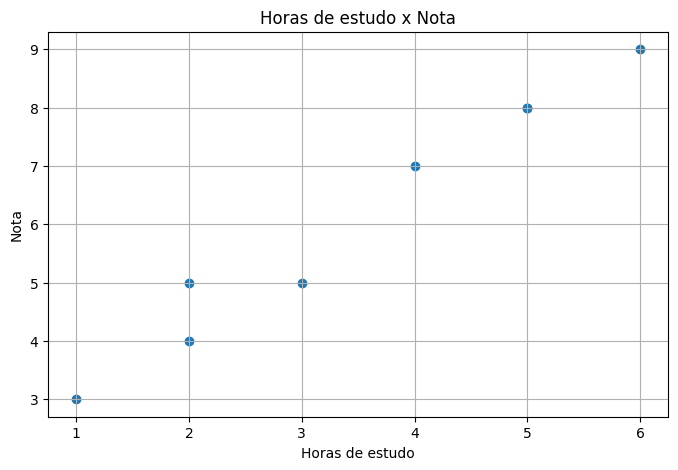

np.float64(0.9853752568539105)

In [54]:
plt.scatter(df_alunos["horas_estudo"], df_alunos["nota"])
plt.title("Horas de estudo x Nota")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota")
plt.grid(True)
plt.show()

df_alunos["horas_estudo"].corr(df_alunos["nota"])

## 13. Interpretação do exemplo

A correlação entre horas de estudo e nota é positiva.

Isso indica que, nesse conjunto de dados, alunos que estudaram mais tenderam a tirar notas maiores.

Mas cuidado:

Isso não prova, sozinho, que estudar mais causou a nota maior.

Podem existir outros fatores:
- qualidade do estudo;
- conhecimento prévio;
- dificuldade da prova;
- sono;
- frequência nas aulas;
- apoio familiar;
- ansiedade.

Correlação é um indício, não uma prova definitiva de causalidade.

## 14. Exemplo: preço e quantidade vendida

Em muitos contextos comerciais, quando o preço aumenta, a quantidade vendida tende a diminuir.

In [55]:
df_vendas = pd.DataFrame({
    "preco": [10, 12, 14, 16, 18, 20, 22, 24],
    "quantidade_vendida": [100, 95, 88, 80, 70, 65, 55, 50]
})

df_vendas

,preco,quantidade_vendida
0,10,100
1,12,95
2,14,88
3,16,80
4,18,70
5,20,65
6,22,55
7,24,50


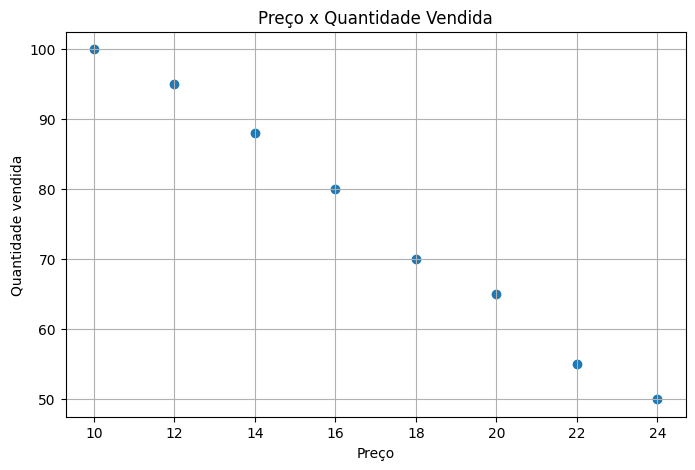

np.float64(-0.9972788722726103)

In [56]:
plt.scatter(df_vendas["preco"], df_vendas["quantidade_vendida"])
plt.title("Preço x Quantidade Vendida")
plt.xlabel("Preço")
plt.ylabel("Quantidade vendida")
plt.grid(True)
plt.show()

df_vendas["preco"].corr(df_vendas["quantidade_vendida"])

## 15. Interpretação do exemplo de vendas

A correlação é negativa.

Isso indica que, nessa base:

- quando o preço aumenta, a quantidade vendida tende a diminuir;
- quando o preço diminui, a quantidade vendida tende a aumentar.

Esse tipo de análise ajuda empresas a entenderem padrões de consumo.

## 16. Correlação fraca

Nem toda relação é forte.

Às vezes, duas variáveis até parecem ter alguma relação, mas os dados estão muito espalhados.

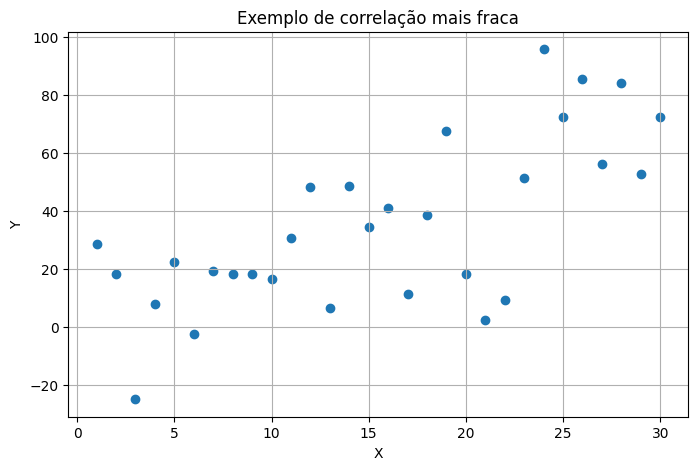

np.float64(0.6966889130146956)

In [57]:
np.random.seed(10)

x = np.arange(1, 31)
y = 2 * x + np.random.normal(0, 20, size=30)

plt.scatter(x, y)
plt.title("Exemplo de correlação mais fraca")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

np.corrcoef(x, y)[0, 1]

## 17. Por que olhar o gráfico é obrigatório?

O coeficiente de correlação resume a relação em um número.

Mas o número sozinho pode enganar.

Sempre que possível:

1. calcule a correlação;
2. faça o gráfico de dispersão;
3. interprete no contexto do problema.

A análise visual ajuda a perceber:
- outliers;
- padrões não lineares;
- grupos diferentes;
- erros nos dados.

## 18. Outliers podem distorcer a correlação

Um único valor extremo pode alterar bastante a correlação.

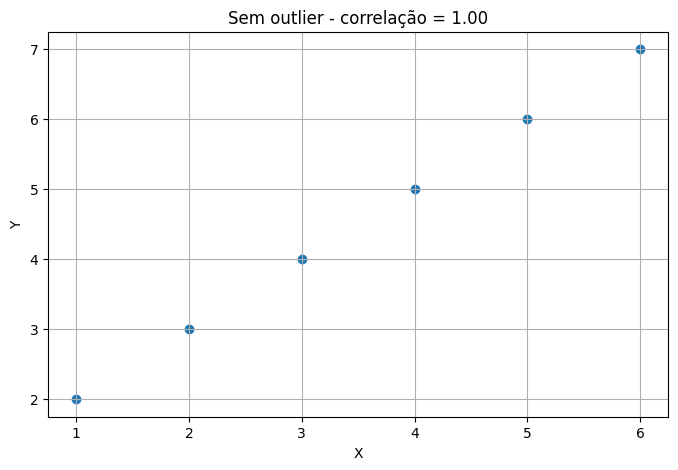

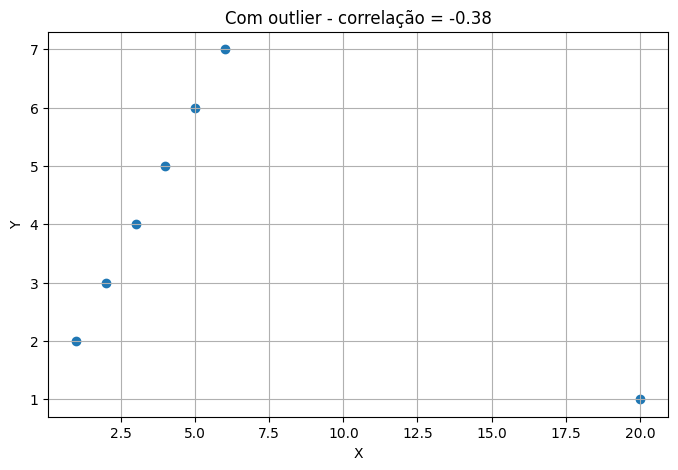

(np.float64(1.0), np.float64(-0.38181916792267817))

In [58]:
x_sem_outlier = np.array([1, 2, 3, 4, 5, 6])
y_sem_outlier = np.array([2, 3, 4, 5, 6, 7])

x_com_outlier = np.array([1, 2, 3, 4, 5, 6, 20])
y_com_outlier = np.array([2, 3, 4, 5, 6, 7, 1])

corr_sem = np.corrcoef(x_sem_outlier, y_sem_outlier)[0, 1]
corr_com = np.corrcoef(x_com_outlier, y_com_outlier)[0, 1]

plt.scatter(x_sem_outlier, y_sem_outlier)
plt.title(f"Sem outlier - correlação = {corr_sem:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

plt.scatter(x_com_outlier, y_com_outlier)
plt.title(f"Com outlier - correlação = {corr_com:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

corr_sem, corr_com

## 19. Interpretação sobre outliers

No primeiro gráfico, a relação é claramente positiva.

No segundo gráfico, adicionamos um ponto extremo.

Esse ponto alterou bastante a correlação.

### Conclusão

Antes de confiar em uma correlação, investigue:
- valores extremos;
- erros de digitação;
- dados faltantes;
- grupos diferentes misturados;
- contexto do problema.

## 20. Correlação mede relação linear

O coeficiente de Pearson mede principalmente relação **linear**.

Isso significa que ele detecta bem relações parecidas com uma linha.

Mas existem relações não lineares.

Exemplo:

\[
y = x^2
\]

Nesse caso, pode existir um padrão forte, mas a correlação linear pode não capturar bem.

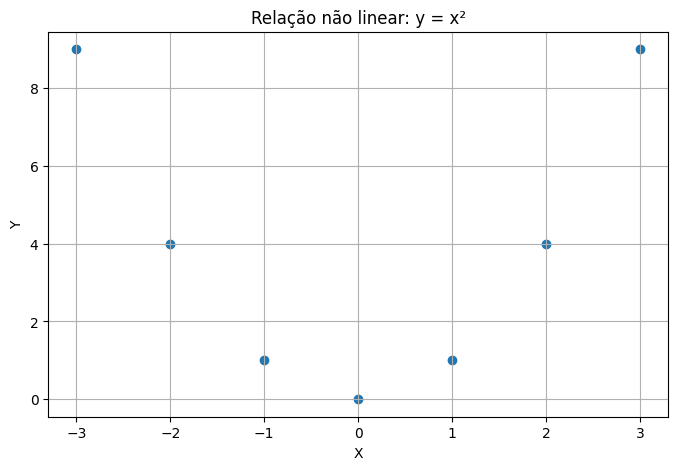

np.float64(0.0)

In [59]:
x = np.array([-3, -2, -1, 0, 1, 2, 3])
y = x**2

plt.scatter(x, y)
plt.title("Relação não linear: y = x²")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

np.corrcoef(x, y)[0, 1]

In [60]:
from scipy.stats import spearmanr, pearsonr

Pearson:  0.9676443927131408
Spearman:  0.9999999999999999


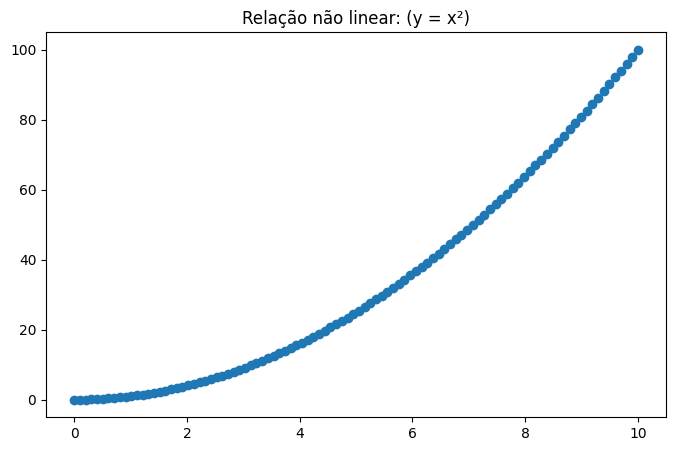

In [61]:
x = np.linspace(0,10,100)
y = x**2

print("Pearson: ", pearsonr(x, y)[0])
print("Spearman: ", spearmanr(x, y)[0])

plt.scatter(x, y)
plt.title("Relação não linear: (y = x²)")
plt.show()




## 21. Interpretação da relação não linear

O gráfico mostra claramente um padrão.

Mas a correlação de Pearson pode ficar próxima de zero porque a relação não é linear.

### Conclusão importante

Correlação baixa não significa necessariamente ausência total de relação.

Pode significar:
- ausência de relação linear;
- relação não linear;
- dados com grupos misturados;
- presença de outliers;
- amostra pequena.

## 22. Matriz de correlação

Quando temos várias variáveis numéricas, podemos calcular a correlação entre todas elas.

Isso gera uma matriz de correlação.

Vamos criar uma base simulada com:

- horas de estudo;
- frequência;
- horas de sono;
- tempo no celular;
- nota.

In [62]:
df = pd.DataFrame({
    "horas_estudo": [1, 2, 2, 3, 4, 5, 5, 6, 7, 8],
    "frequencia": [60, 65, 70, 72, 78, 82, 85, 88, 92, 95],
    "horas_sono": [5, 6, 5, 6, 7, 7, 8, 7, 8, 8],
    "tempo_celular": [8, 7, 7, 6, 5, 4, 4, 3, 2, 2],
    "nota": [3, 4, 5, 5, 6, 7, 8, 8, 9, 10]
})

df

,horas_estudo,frequencia,horas_sono,tempo_celular,nota
0,1,60,5,8,3
1,2,65,6,7,4
2,2,70,5,7,5
3,3,72,6,6,5
4,4,78,7,5,6
5,5,82,7,4,7
6,5,85,8,4,8
7,6,88,7,3,8
8,7,92,8,2,9
9,8,95,8,2,10


In [63]:
matriz_corr = df.corr(numeric_only=True)
matriz_corr

,horas_estudo,frequencia,horas_sono,tempo_celular,nota
horas_estudo,1.000000,0.987157,0.907776,-0.992576,0.983227
frequencia,0.987157,1.000000,0.907702,-0.989658,0.993995
horas_sono,0.907776,0.907702,1.000000,-0.918180,0.906399
tempo_celular,-0.992576,-0.989658,-0.918180,1.000000,-0.977677
nota,0.983227,0.993995,0.906399,-0.977677,1.000000


## 23. Interpretando a matriz de correlação

Na matriz:

- valores próximos de +1 indicam forte relação positiva;
--
frequencia e hora destudo
- valores próximos de -1 indicam forte relação negativa;
--
tempo de celular
- valores próximos de 0 indicam relação linear fraca.
--
não

Observe especialmente a coluna `nota`.

Perguntas importantes:
- Quais variáveis têm maior correlação positiva com a nota?
- Quais variáveis têm correlação negativa com a nota?
- Existe alguma variável aparentemente pouco relacionada?

## 24. Heatmap de correlação

O heatmap é uma forma visual de apresentar a matriz de correlação.

Vamos usar `seaborn` para facilitar a visualização.

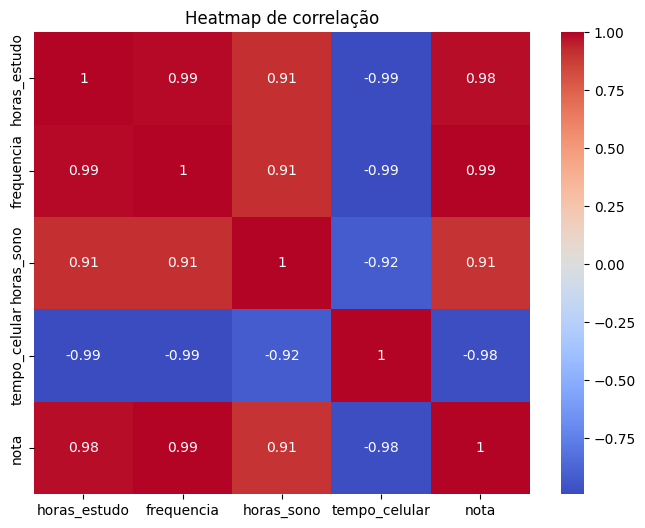

In [64]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap de correlação")
plt.show()

## 25. Como usar correlação em IA

Correlação ajuda em várias etapas de projetos de IA:

### 1. Análise exploratória de dados
Antes de treinar modelos, queremos entender os dados.

### 2. Escolha de variáveis
Variáveis muito relacionadas ao alvo podem ser úteis para previsão.

### 3. Remoção de variáveis pouco úteis
Variáveis com baixa relação com o alvo podem ser menos informativas.

### 4. Identificação de redundância
Se duas variáveis são muito correlacionadas entre si, talvez carreguem informação parecida.

### 5. Preparação para regressão
Correlação ajuda a perceber se faz sentido tentar prever uma variável com base em outra.

### 6. Detecção de problemas
Correlações inesperadas podem indicar:
- vazamento de dados;
- erro de coleta;
- variável mal construída;
- informação duplicada.

## 26. Atenção: correlação entre variáveis explicativas

Em IA, não olhamos apenas a correlação com o alvo.

Também observamos correlação entre as próprias variáveis de entrada.

Exemplo:

- renda mensal;
- renda anual.

Essas duas variáveis provavelmente terão correlação altíssima.

Isso pode gerar redundância.

Em alguns modelos, esse problema é chamado de **multicolinearidade**.

### Ideia prática
Se duas variáveis dizem quase a mesma coisa, talvez não seja necessário usar as duas.

## 27. Ponte para regressão

Correlação ajuda a responder:

> Existe relação entre as variáveis?

Regressão tenta responder:

> Posso usar essa relação para fazer uma previsão?

Exemplo:

Se horas de estudo e nota têm correlação positiva forte, podemos tentar criar um modelo para prever nota a partir das horas de estudo.

Correlação descobre o padrão.  
Regressão tenta modelar esse padrão.

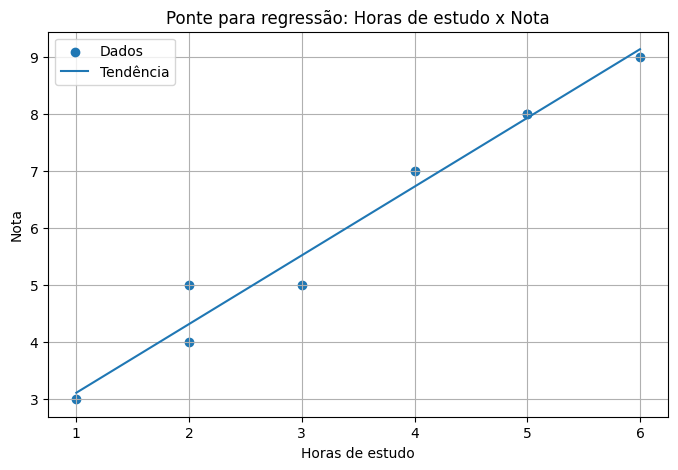

array([1.20454545, 1.90909091])

In [65]:
# Exemplo simples de linha de tendência visual

horas = df_alunos["horas_estudo"]
notas = df_alunos["nota"]

coef = np.polyfit(horas, notas, 1)
linha = np.poly1d(coef)

plt.scatter(horas, notas, label="Dados")
plt.plot(horas, linha(horas), label="Tendência")
plt.title("Ponte para regressão: Horas de estudo x Nota")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota")
plt.grid(True)
plt.legend()
plt.show()

coef

## 28. Interpretação da ponte para regressão

O gráfico mostra os pontos reais e uma linha de tendência.

Essa linha é uma ideia inicial de regressão.

Na próxima aula, podemos sair da pergunta:

> Existe relação?

Para a pergunta:

> Como prever um valor usando essa relação?

# Exercícios resolvidos

## Exercício resolvido 1

Uma turma apresentou os dados:

| Horas de estudo | Nota |
|---|---|
| 1 | 2 |
| 2 | 4 |
| 3 | 6 |
| 4 | 8 |

A relação parece positiva, negativa ou inexistente?

### Resposta

Positiva.

Quanto maior o número de horas de estudo, maior a nota.

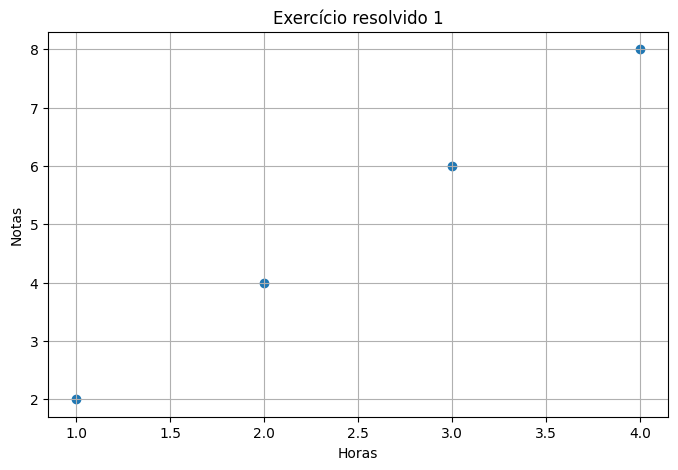

np.float64(1.0)

In [66]:
horas = [1, 2, 3, 4]
notas = [2, 4, 6, 8]

plt.scatter(horas, notas)
plt.title("Exercício resolvido 1")
plt.xlabel("Horas")
plt.ylabel("Notas")
plt.grid(True)
plt.show()

np.corrcoef(horas, notas)[0, 1]

## Exercício resolvido 2

Uma loja analisou:

| Preço | Quantidade vendida |
|---|---|
| 10 | 100 |
| 20 | 80 |
| 30 | 60 |
| 40 | 40 |

A relação parece positiva ou negativa?

### Resposta

Negativa.

Quando o preço aumenta, a quantidade vendida diminui.

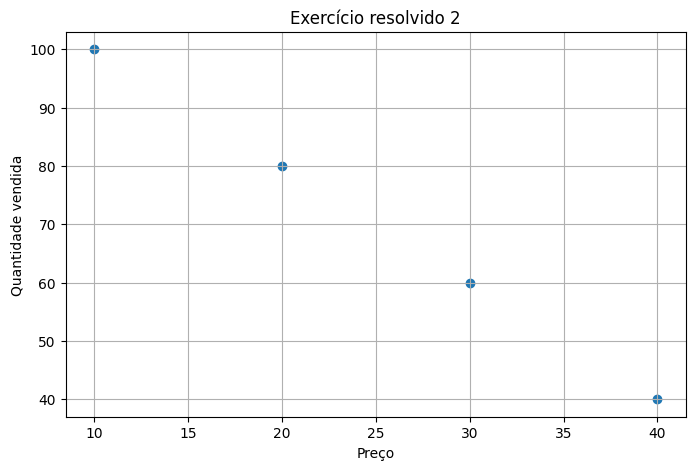

np.float64(-1.0)

In [67]:
preco = [10, 20, 30, 40]
qtd = [100, 80, 60, 40]

plt.scatter(preco, qtd)
plt.title("Exercício resolvido 2")
plt.xlabel("Preço")
plt.ylabel("Quantidade vendida")
plt.grid(True)
plt.show()

np.corrcoef(preco, qtd)[0, 1]

## Exercício resolvido 3

Se a correlação entre duas variáveis é 0,92, o que podemos concluir?

### Resposta

Existe uma correlação positiva muito forte.

Quando uma variável aumenta, a outra tende a aumentar também.

Mas isso não prova causalidade.

# Lista de exercícios – Parte A: Conceitos

### Exercício 1
Explique, com suas palavras, o que é correlação.

### Exercício 2
Qual a diferença entre correlação positiva e correlação negativa?

### Exercício 3
O que significa dizer que a correlação é próxima de zero?

### Exercício 4
Por que correlação não significa causalidade?

### Exercício 5
Dê um exemplo de correlação positiva no mundo real.

### Exercício 6
Dê um exemplo de correlação negativa no mundo real.

### Exercício 7
Dê um exemplo de duas variáveis que provavelmente não têm correlação.

### Exercício 8
Por que o gráfico de dispersão é importante antes de confiar apenas no coeficiente de correlação?

### Exercício 9
O que é uma correlação espúria?

### Exercício 10
Explique o que significa uma variável escondida ou fator de confusão.

In [68]:
#medida que indica como duas variáveis mudam juntas

In [69]:
# positiva -> ambas crescem juntas
# negativa -> uma cresce enquanto a outra diminui

In [70]:
# significa que não existe uma relação linear entre as variáveis
# relação pode ser coincidência ou causada por um terceiro fator

In [71]:
# quanto maior a área de um imóvel, maior tende a ser o preço
# quanto maior a altitude de um local, menor tende a ser a temperatura
# o preço do aluguel em Brasília e a quantidade de chuva em Tóquio
# identificar padrões não lineares ou outliers que o coeficiente sozinho ignora

In [72]:
# correlação forte entre variáveis que não possuem relação lógica real
# terceiro fator não medido que influencia as duas variáveis ao mesmo tempo

# Lista de exercícios – Parte B: Interpretação de valores

### Exercício 11
Interprete r = 0,95.

### Exercício 12
Interprete r = -0,88.

### Exercício 13
Interprete r = 0,12.

### Exercício 14
Interprete r = -0,35.

### Exercício 15
Interprete r = 0,62.

### Exercício 16
Qual correlação é mais forte: r = 0,75 ou r = -0,82? Explique.

### Exercício 17
Se duas variáveis têm r = 1, o que isso significa?

### Exercício 18
Se duas variáveis têm r = -1, o que isso significa?

### Exercício 19
Se duas variáveis têm r = 0, isso garante que não existe nenhuma relação entre elas? Explique.

### Exercício 20
Uma correlação de 0,80 prova que uma variável causa a outra? Explique.

In [73]:
"""
positiva muito forte, as variáveis crescem quase perfeitamente juntas
negativa forte, uma variável cresce, a outra desce drasticamente
positiva muito fraca ou desprezível, quase não há relação linear
negativa fraca, uma cair enquanto a outra sobe
ositiva moderada; existe uma relação visível, mas com dispersão
r = -0,82$ é mais forte
positiva perfeita, todos os pontos formam uma linha reta ascendente
negativa perfeita, todos os pontos formam uma linha reta descendente
não, garante apenas que não há relação linear, mas pode haver relação curva
não, prova apenas associação, não prova que uma é a causa da outra
"""

'\npositiva muito forte, as variáveis crescem quase perfeitamente juntas\nnegativa forte, uma variável cresce, a outra desce drasticamente\npositiva muito fraca ou desprezível, quase não há relação linear\nnegativa fraca, uma cair enquanto a outra sobe\nositiva moderada; existe uma relação visível, mas com dispersão\nr = -0,82$ é mais forte\npositiva perfeita, todos os pontos formam uma linha reta ascendente\nnegativa perfeita, todos os pontos formam uma linha reta descendente\nnão, garante apenas que não há relação linear, mas pode haver relação curva\nnão, prova apenas associação, não prova que uma é a causa da outra\n'

# Lista de exercícios – Parte C: Gráficos

Para cada caso abaixo, faça um gráfico de dispersão e interprete o tipo de correlação.

### Exercício 21
```python
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]
```

### Exercício 22
```python
x = [1, 2, 3, 4, 5]
y = [10, 8, 6, 4, 2]
```

### Exercício 23
```python
x = [1, 2, 3, 4, 5]
y = [5, 1, 9, 2, 7]
```

### Exercício 24
```python
x = [10, 20, 30, 40, 50]
y = [100, 90, 70, 60, 40]
```

### Exercício 25
```python
x = [2, 4, 6, 8, 10]
y = [3, 3, 4, 4, 5]
```

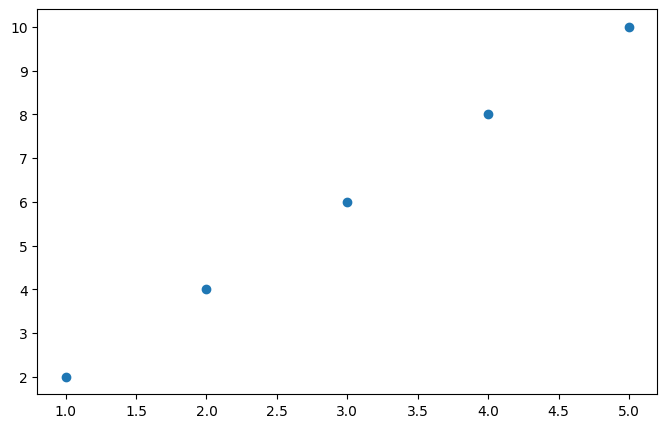

In [74]:
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

plt.scatter(x, y)
plt.show()
# correlação positiva forte

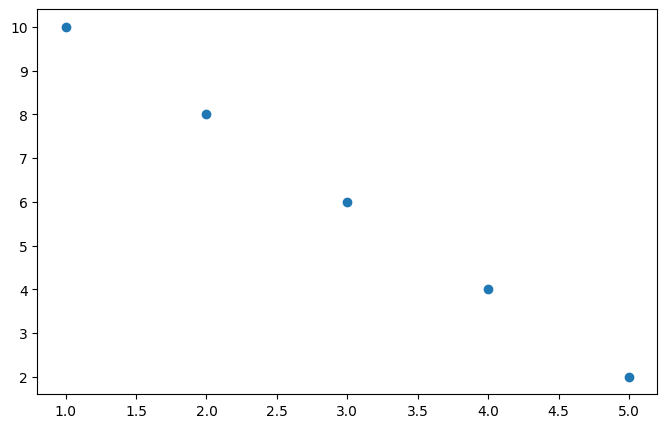

In [75]:
x = [1, 2, 3, 4, 5]
y = [10, 8, 6, 4, 2]

plt.scatter(x, y)
plt.show()
# correlação negativa forte

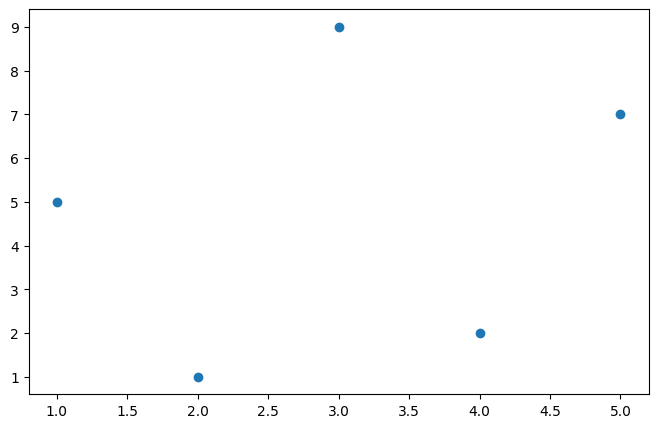

In [76]:
x = [1, 2, 3, 4, 5]
y = [5, 1, 9, 2, 7]

plt.scatter(x, y)
plt.show()
# não está claro

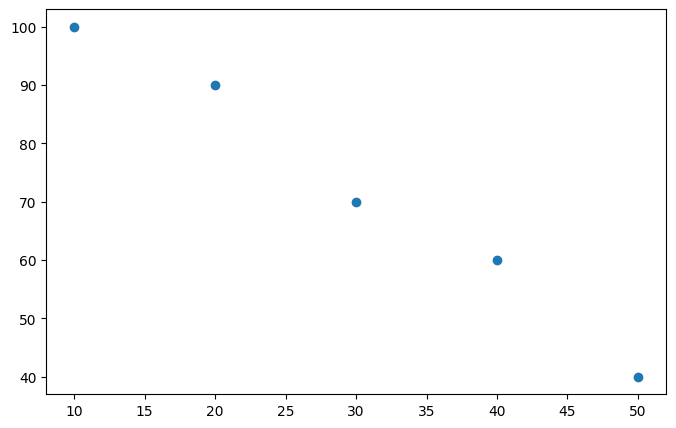

In [77]:
x = [10, 20, 30, 40, 50]
y = [100, 90, 70, 60, 40]

plt.scatter(x, y)
plt.show()
# correlação negativa

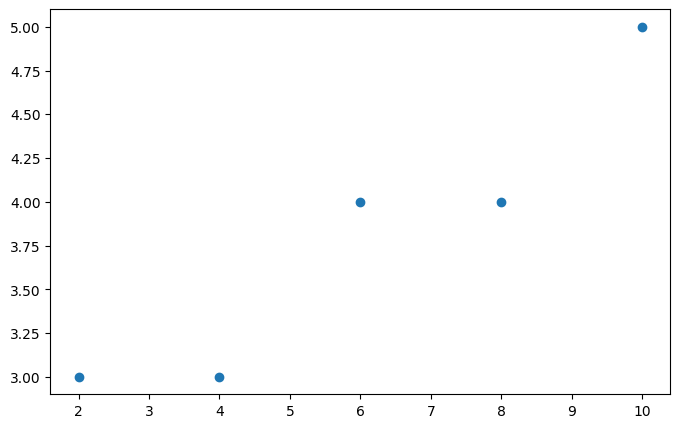

In [78]:
x = [2, 4, 6, 8, 10]
y = [3, 3, 4, 4, 5]

plt.scatter(x, y)
plt.show()
# positiva fraca

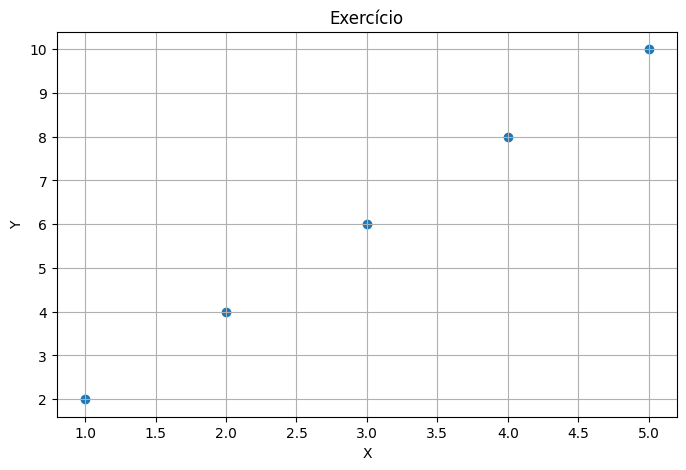

np.float64(0.9999999999999999)

In [79]:
# Espaço para os exercícios da Parte C

x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

plt.scatter(x, y)
plt.title("Exercício")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

np.corrcoef(x, y)[0, 1]

# Lista de exercícios – Parte D: Aplicação com DataFrame

Vamos trabalhar com uma base simulada de uma loja.

In [80]:
df_loja = pd.DataFrame({
    "publicidade": [100, 200, 300, 400, 500, 600, 700, 800],
    "vendas": [20, 35, 45, 60, 75, 85, 95, 110],
    "preco": [50, 48, 47, 45, 43, 42, 40, 39],
    "satisfacao": [6, 6.5, 7, 7.2, 7.8, 8, 8.5, 9],
    "reclamacoes": [20, 18, 15, 14, 10, 9, 7, 5]
})

df_loja

,publicidade,vendas,preco,satisfacao,reclamacoes
0,100,20,50,6.0,20
1,200,35,48,6.5,18
2,300,45,47,7.0,15
3,400,60,45,7.2,14
4,500,75,43,7.8,10
5,600,85,42,8.0,9
6,700,95,40,8.5,7
7,800,110,39,9.0,5


### Exercício 26
Calcule a matriz de correlação da base `df_loja`.

### Exercício 27
Qual variável tem maior correlação positiva com vendas?

### Exercício 28
Qual variável tem maior correlação negativa com reclamações?

### Exercício 29
Publicidade e vendas parecem relacionadas?

### Exercício 30
Preço e vendas parecem relacionadas?

### Exercício 31
Satisfação e reclamações parecem relacionadas?

### Exercício 32
Faça um heatmap da matriz de correlação.

### Exercício 33
Escolha duas variáveis e faça um gráfico de dispersão.

### Exercício 34
Com base nas correlações, quais variáveis você investigaria melhor para prever vendas?

### Exercício 35
Alguma correlação poderia ser confundida com causalidade? Explique.

In [88]:
corr = df_loja.corr()
print(corr)

             publicidade    vendas     preco  satisfacao  reclamacoes
publicidade     1.000000  0.998483 -0.997117    0.996229    -0.994135
vendas          0.998483  1.000000 -0.997696    0.995446    -0.994777
preco          -0.997117 -0.997696  1.000000   -0.993442     0.993544
satisfacao      0.996229  0.995446 -0.993442    1.000000    -0.996111
reclamacoes    -0.994135 -0.994777  0.993544   -0.996111     1.000000


In [95]:
print(corr["vendas"].sort_values(ascending=False))
# publicidade

vendas         1.000000
publicidade    0.998483
satisfacao     0.995446
reclamacoes   -0.994777
preco         -0.997696
Name: vendas, dtype: float64


In [96]:
print(corr["reclamacoes"].sort_values())
# satisfação

satisfacao    -0.996111
vendas        -0.994777
publicidade   -0.994135
preco          0.993544
reclamacoes    1.000000
Name: reclamacoes, dtype: float64


In [97]:
# publicidade e vendas alta positiva

In [98]:
# preço e vendas correlação negativa

In [99]:
# satisfação e reclamações correlação negativa forte

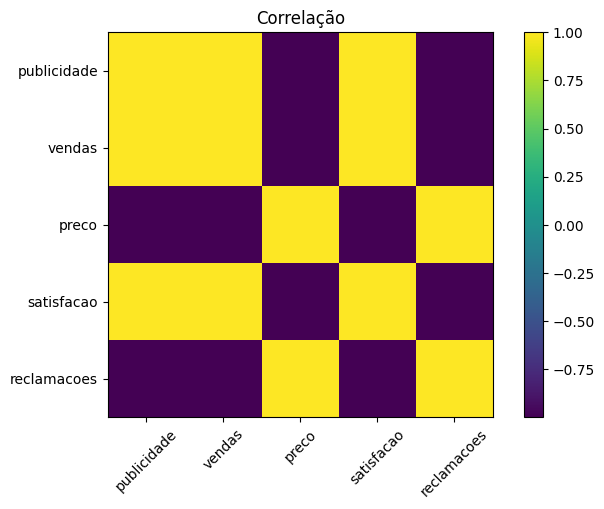

In [101]:
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlação")
plt.show()

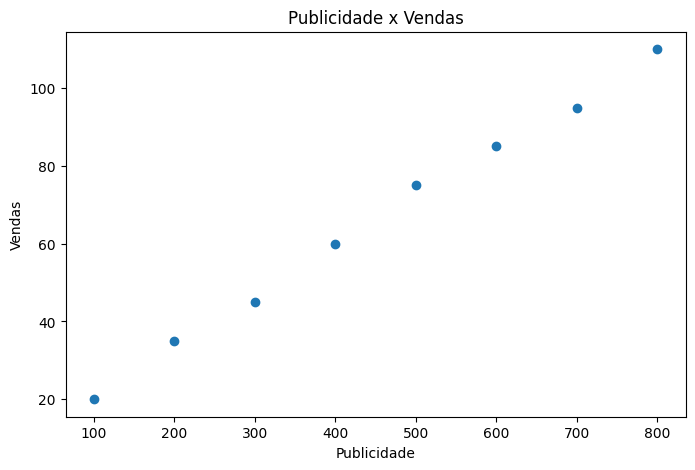

In [102]:
plt.scatter(df_loja["publicidade"], df_loja["vendas"])
plt.title("Publicidade x Vendas")
plt.xlabel("Publicidade")
plt.ylabel("Vendas")
plt.show()

In [ ]:
# publicidade, preco, satisfacao

In [103]:
# correlação não implica causalidade

In [81]:
# Espaço para análise da base da loja

corr_loja = df_loja.corr(numeric_only=True)
corr_loja

,publicidade,vendas,preco,satisfacao,reclamacoes
publicidade,1.000000,0.998483,-0.997117,0.996229,-0.994135
vendas,0.998483,1.000000,-0.997696,0.995446,-0.994777
preco,-0.997117,-0.997696,1.000000,-0.993442,0.993544
satisfacao,0.996229,0.995446,-0.993442,1.000000,-0.996111
reclamacoes,-0.994135,-0.994777,0.993544,-0.996111,1.000000


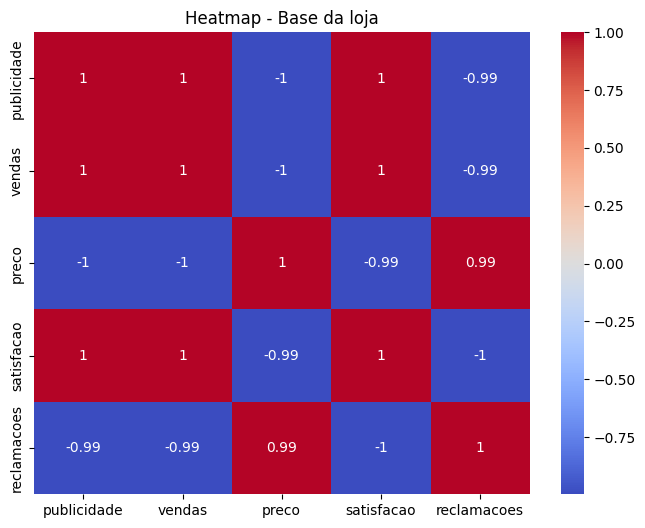

In [82]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_loja, annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap - Base da loja")
plt.show()

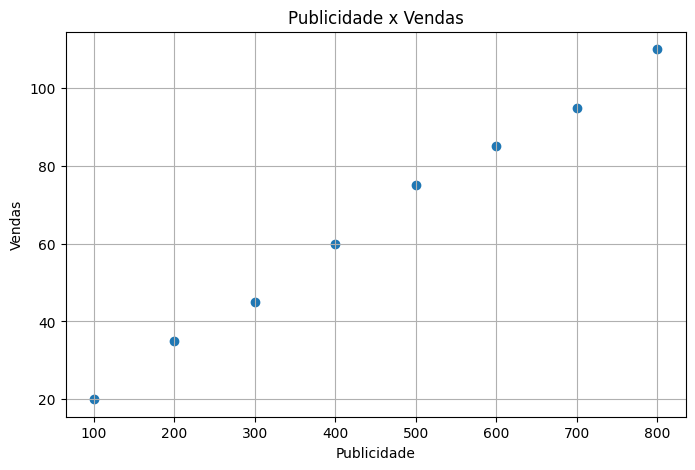

np.float64(0.9984825984991279)

In [83]:
plt.scatter(df_loja["publicidade"], df_loja["vendas"])
plt.title("Publicidade x Vendas")
plt.xlabel("Publicidade")
plt.ylabel("Vendas")
plt.grid(True)
plt.show()

df_loja["publicidade"].corr(df_loja["vendas"])

# Lista de exercícios – Parte E: IA e tomada de decisão

### Exercício 36
Explique como correlação pode ajudar na escolha de variáveis para um modelo de IA.

### Exercício 37
Explique por que uma variável com baixa correlação com o alvo pode ser menos útil.

### Exercício 38
Uma variável com alta correlação com o alvo deve ser usada automaticamente no modelo? Explique.

### Exercício 39
Por que correlação entre variáveis explicativas pode ser um problema?

### Exercício 40
Explique a diferença entre descobrir padrão e fazer previsão.

### Exercício 41
Como a correlação prepara o caminho para regressão?

### Exercício 42
Dê um exemplo de situação em que uma correlação forte pode levar a uma decisão errada.

# Desafio final – Caso aplicado

Uma escola coletou dados de 12 alunos:

- horas de estudo por semana;
- frequência nas aulas;
- tempo diário no celular;
- horas de sono;
- nota final.

Você deve investigar quais variáveis parecem mais relacionadas com a nota final.

In [84]:
df_escola = pd.DataFrame({
    "horas_estudo": [1, 2, 2, 3, 4, 4, 5, 5, 6, 7, 7, 8],
    "frequencia": [55, 60, 62, 68, 72, 75, 80, 82, 88, 90, 94, 96],
    "tempo_celular": [9, 8, 8, 7, 6, 6, 5, 5, 4, 3, 3, 2],
    "horas_sono": [5, 5, 6, 6, 6, 7, 7, 7, 8, 8, 8, 9],
    "nota_final": [3, 4, 4.5, 5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5]
})

df_escola

,horas_estudo,frequencia,tempo_celular,horas_sono,nota_final
0,1,55,9,5,3.0
1,2,60,8,5,4.0
2,2,62,8,6,4.5
3,3,68,7,6,5.0
4,4,72,6,6,6.0
5,4,75,6,7,6.5
6,5,80,5,7,7.0
7,5,82,5,7,7.5
8,6,88,4,8,8.0
9,7,90,3,8,8.5


## Tarefas do desafio

1. Calcule a matriz de correlação.
2. Faça um heatmap.
3. Identifique a variável com maior correlação positiva com a nota final.
4. Identifique a variável com maior correlação negativa com a nota final.
5. Faça gráficos de dispersão entre:
   - horas de estudo e nota final;
   - tempo no celular e nota final;
   - frequência e nota final.
6. Interprete os resultados.
7. Explique por que isso não prova causalidade.
8. Escolha duas variáveis que você usaria em um modelo para prever a nota.
9. Justifique sua escolha.
10. Escreva uma conclusão como se fosse apresentar para a coordenação da escola.

In [85]:
corr_escola = df_escola.corr(numeric_only=True)
corr_escola

,horas_estudo,frequencia,tempo_celular,horas_sono,nota_final
horas_estudo,1.000000,0.993007,-1.000000,0.962415,0.990519
frequencia,0.993007,1.000000,-0.993007,0.968169,0.996431
tempo_celular,-1.000000,-0.993007,1.000000,-0.962415,-0.990519
horas_sono,0.962415,0.968169,-0.962415,1.000000,0.967118
nota_final,0.990519,0.996431,-0.990519,0.967118,1.000000


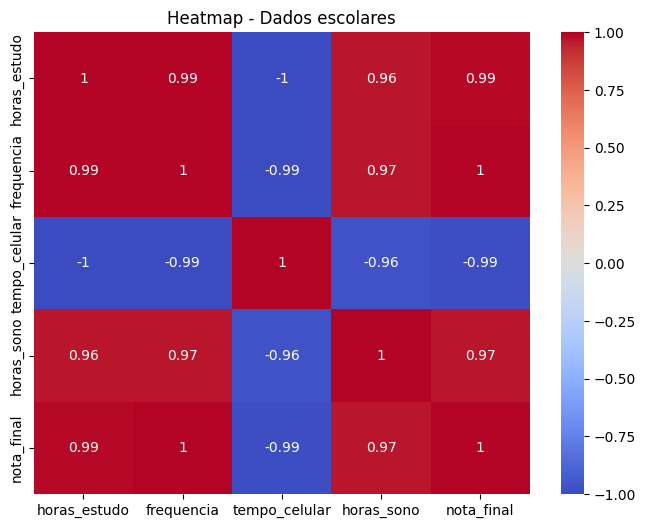

In [86]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_escola, annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap - Dados escolares")
plt.show()

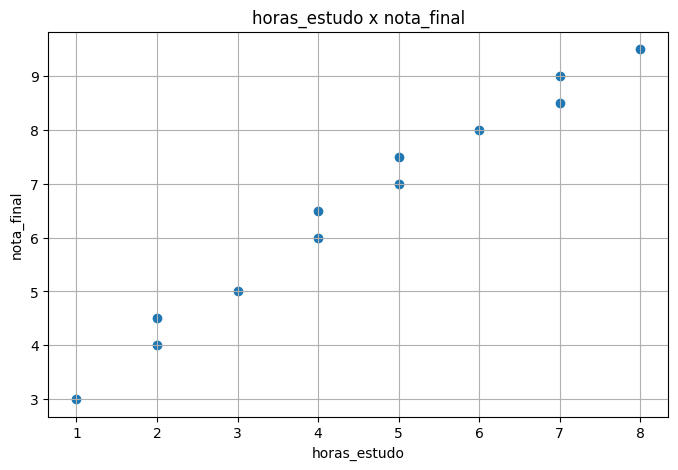

Correlação entre horas_estudo e nota_final: 0.9905189210845331


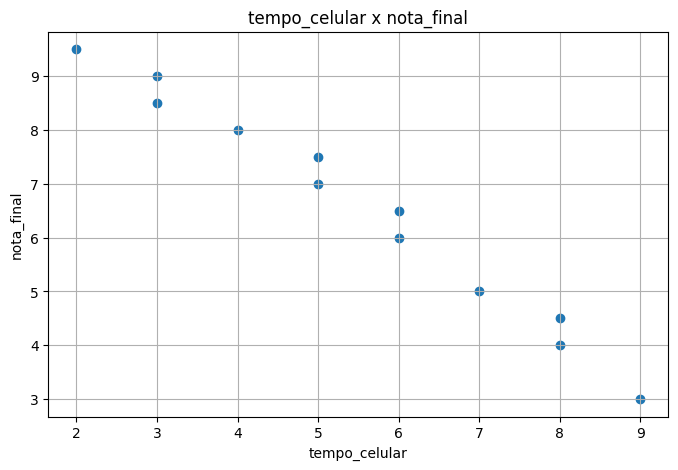

Correlação entre tempo_celular e nota_final: -0.9905189210845331


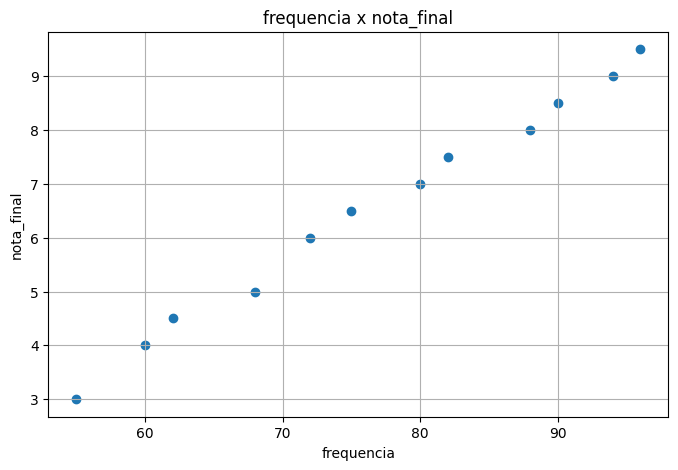

Correlação entre frequencia e nota_final: 0.9964313236761321


In [87]:
variaveis = ["horas_estudo", "tempo_celular", "frequencia"]

for var in variaveis:
    plt.scatter(df_escola[var], df_escola["nota_final"])
    plt.title(f"{var} x nota_final")
    plt.xlabel(var)
    plt.ylabel("nota_final")
    plt.grid(True)
    plt.show()
    print(f"Correlação entre {var} e nota_final:", df_escola[var].corr(df_escola["nota_final"]))

# Gabarito curto – ideias principais

- Correlação mede associação entre duas variáveis.
- Correlação positiva: as duas variáveis tendem a subir juntas.
- Correlação negativa: uma variável tende a subir enquanto a outra desce.
- Correlação próxima de zero: não há relação linear clara.
- Correlação não prova causalidade.
- Gráfico de dispersão é essencial para interpretar a relação.
- Outliers podem distorcer a correlação.
- Pearson mede relação linear.
- Relações não lineares podem ter correlação baixa.
- Matriz de correlação ajuda a analisar várias variáveis ao mesmo tempo.
- Heatmap facilita a interpretação visual.
- Em IA, correlação ajuda na análise exploratória e escolha de variáveis.
- Correlação é uma ponte natural para regressão.

# Fechamento

Nesta aula, aprendemos que correlação é uma ferramenta para descobrir padrões entre variáveis.

A grande mudança de pensamento é:

> Antes, analisávamos uma variável por vez.  
> Agora, começamos a analisar como variáveis se relacionam.

Isso é essencial para Inteligência Artificial, porque modelos aprendem padrões a partir das relações entre variáveis.

Na próxima etapa, podemos avançar para regressão:

> Se existe uma relação entre variáveis, podemos usar essa relação para prever valores?